<a href="https://colab.research.google.com/github/JurniahHolipah/ATM_SIMULATOR/blob/main/student_score_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Student Score Regression Project

Notebook ini berisi langkah-langkah untuk mengerjakan assignment:
1. Gunakan dataset student score
2. Lakukan Exploratory Data Analysis (EDA)
3. Lakukan Feature Engineering (cek duplikat, missing value, outlier)
4. Lakukan pemodelan minimal 2 model (Linear Regression, Decision Tree, Random Forest)
5. Evaluasi model
6. Berikan kesimpulan model terbaik

In [ ]:
# 1. Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# 2. Load Dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving student_scores.csv to student_scores (2).csv


,Hours,Score
0,1.1,17
1,2.5,21
2,3.2,27
3,4.5,30
4,5.5,42


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   20 non-null     float64
 1   Score   20 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 452.0 bytes
None
           Hours      Score
count  20.000000  20.000000
mean    5.960000  52.400000
std     2.952501  26.206468
min     1.100000  17.000000
25%     3.650000  29.250000
50%     5.800000  48.000000
75%     8.600000  76.250000
max    10.500000  95.000000
Hours    0
Score    0
dtype: int64


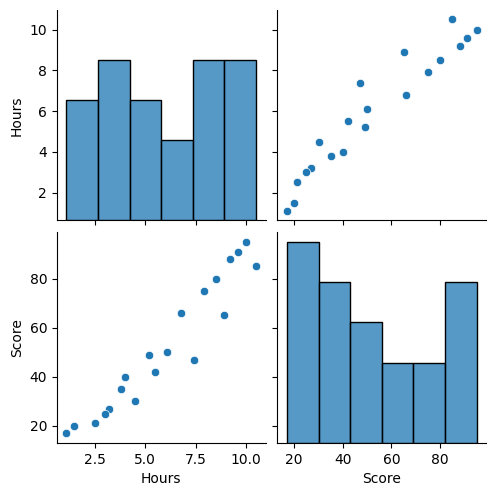

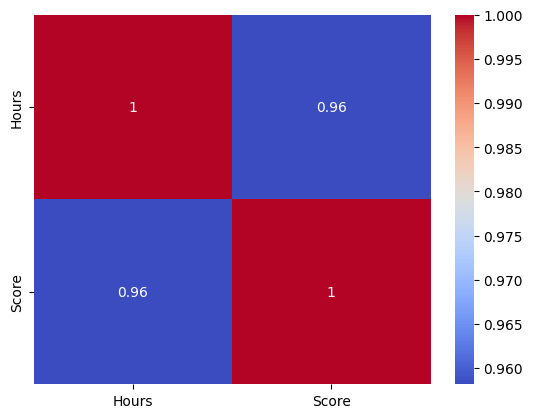

In [ ]:
# 3. Exploratory Data Analysis (EDA)
print(df.info())
print(df.describe())
print(df.isnull().sum())

sns.pairplot(df)
plt.show()

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

=== Check Duplicated Data ===
Jumlah data duplikat: 0
Tidak ada data duplikat.

=== Check Missing Value ===
Hours    0
Score    0
dtype: int64

=== Outlier Analysis dengan Boxplot ===


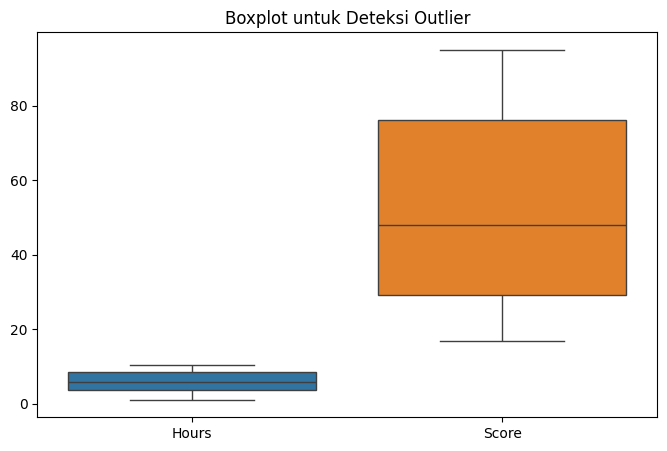


Jumlah outlier per kolom:
    Hours  Score
0   False  False
1   False  False
2   False  False
3   False  False
4   False  False
5   False  False
6   False  False
7   False  False
8   False  False
9   False  False
10  False  False
11  False  False
12  False  False
13  False  False
14  False  False
15  False  False
16  False  False
17  False  False
18  False  False
19  False  False


In [ ]:
# 4. Feature Engineering

# 1. Check Duplicated Data
print("=== Check Duplicated Data ===")
duplicates = df.duplicated().sum()
print("Jumlah data duplikat:", duplicates)

# Jika ada duplikat, hapus dengan drop_duplicates()
if duplicates > 0:
  df = df.drop_duplicates()
  print("Data duplikat berhasil dihapus!")
else:
  print("Tidak ada data duplikat.")

# 2. Check Missing Value
print("\n=== Check Missing Value ===")
print(df.isnull().sum())

# Contoh handling misiing value (jika ada)
df = df.fillna(df.mean())    # Imputasi rata rata
df = df.dropna()             # Atau hapus baris yang kosong

# 3. Outlier Analysis
print("\n=== Outlier Analysis dengan Boxplot ===")
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(data=df)
plt.title("Boxplot untuk Deteksi Outlier")
plt.show()

# Untuk mendeteksi nilai outlier secara numerik (IQR method)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))
print("\nJumlah outlier per kolom:")
print(outliers)



In [ ]:
# 5. Modelling
X = df.drop("Score", axis=1)  # ganti 'score' dengan kolom target dataset
y = df["Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
# 6. Evaluasi Model
def evaluate_model(y_true, y_pred, model_name):
    print(f"=== {model_name} ===")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("MSE :", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))
    print("\n")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")

=== Linear Regression ===
MAE : 5.585073673693262
MSE : 39.028140520022134
RMSE: 6.247250636881966
R2 Score: 0.9483413097021547


=== Decision Tree ===
MAE : 10.25
MSE : 152.75
RMSE: 12.359207094308275
R2 Score: 0.7978160158835208


=== Random Forest ===
MAE : 9.3875
MSE : 114.35782500000003
RMSE: 10.693821814487093
R2 Score: 0.8486329252150893




## 📌 Kesimpulan
- Bandingkan nilai R² dan RMSE dari ketiga model.
- Semakin tinggi R² dan semakin kecil RMSE, semakin baik performa model.
- Tuliskan di bagian ini model mana yang terbaik untuk dataset kamu.